# 03 — Model Exploration

Seven models evaluated on next-day 10Y Treasury forecasting using a walk-forward backtest. The two strongest models are then tuned via hyperparameter search. Best predictions and fitted models are saved for ensemble construction in notebook 04.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib, os
from sklearn.base import clone
from sklearn.linear_model import Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})

df = pd.read_csv('../data/engineered_features.csv', parse_dates=['date'], index_col='date')

TARGET      = '10_yr'          # primary exploration target
HORIZON     = 1                # days ahead
MIN_TRAIN   = 252              # 1 year minimum training window
REFIT_EVERY = 5

target_cols  = ['fred_sofr', '1_mo', '1_yr', '5_yr', '10_yr']
feature_cols = [c for c in df.columns if c not in target_cols]
X = df[feature_cols]
y = df[TARGET].shift(-HORIZON).rename('target')

print(f"Features: {len(feature_cols)}  |  Targets: {target_cols}")
print(f"Training obs available: {y.notna().sum()}")

Features: 23  |  Targets: ['fred_sofr', '1_mo', '1_yr', '5_yr', '10_yr']
Training obs available: 748


## Model Library

Seven candidates ranging from simple linear baselines to non-linear ensembles. All are evaluated with identical walk-forward backtests so results are directly comparable.

In [2]:
models = {
    'Ridge':    make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    'Lasso':    make_pipeline(StandardScaler(), Lasso(alpha=0.001, max_iter=5000)),
    'ElasticNet': make_pipeline(StandardScaler(), ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000)),
    'Huber':    make_pipeline(StandardScaler(), HuberRegressor(epsilon=1.35, max_iter=300)),
    'RF':       RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=10, random_state=42, n_jobs=-1),
    'GBR':      GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=200, max_depth=6, min_samples_leaf=10, random_state=42, n_jobs=-1),
}

print(f"Models defined: {list(models.keys())}")

Models defined: ['Ridge', 'Lasso', 'ElasticNet', 'Huber', 'RF', 'GBR', 'ExtraTrees']


## Walk-Forward Backtest

Expanding window: start with `MIN_TRAIN` days, predict one step ahead, add that day to training, repeat. The model is refit every `REFIT_EVERY` days to balance accuracy and speed. This is the same protocol used across all experiments so comparisons are apples-to-apples.

In [3]:
def walk_forward(model, X, y, min_train=MIN_TRAIN, refit_every=REFIT_EVERY):
    """Expanding-window walk-forward backtest. Returns Series of predictions aligned to y's index."""
    aligned = y.dropna()
    X_aligned = X.loc[aligned.index]
    idx = aligned.index

    preds = {}
    fit = None
    for i in range(min_train, len(idx)):
        if fit is None or (i - min_train) % refit_every == 0:
            X_tr = X_aligned.iloc[:i]
            y_tr = aligned.iloc[:i]
            fit = clone(model).fit(X_tr, y_tr)
        preds[idx[i]] = fit.predict(X_aligned.iloc[[i]])[0]

    return pd.Series(preds, name='prediction')


def eval_metrics(y_true, y_pred):
    mae   = mean_absolute_error(y_true, y_pred) * 100   # → basis points
    rmse  = np.sqrt(np.mean((y_true - y_pred) ** 2)) * 100
    r2    = r2_score(y_true, y_pred)
    dir_acc = np.mean(np.sign(y_true.diff().dropna()) == np.sign(y_pred.diff().dropna())) * 100
    bias  = (y_pred - y_true).mean() * 100
    return dict(MAE_bps=round(mae, 2), RMSE_bps=round(rmse, 2),
                R2=round(r2, 4), Dir_Acc_pct=round(dir_acc, 1), Bias_bps=round(bias, 2))


print("walk_forward() and eval_metrics() defined")

walk_forward() and eval_metrics() defined


## Baseline Comparison — All 7 Models on 10Y Next-Day

Run each model through the walk-forward protocol and record MAE, RMSE, R², directional accuracy, and bias.

In [4]:
baseline_results = {}
baseline_preds   = {}

for name, mdl in models.items():
    preds = walk_forward(mdl, X, y)
    actual = y.loc[preds.index]
    baseline_results[name] = eval_metrics(actual, preds)
    baseline_preds[name]   = preds
    print(f"  {name:12s}  MAE={baseline_results[name]['MAE_bps']:.2f} bps  "
          f"R²={baseline_results[name]['R2']:.4f}  "
          f"Dir={baseline_results[name]['Dir_Acc_pct']:.1f}%")

results_df = pd.DataFrame(baseline_results).T
print("\n", results_df.to_string())

  Ridge         MAE=4.94 bps  R²=0.9082  Dir=46.5%


  Lasso         MAE=4.89 bps  R²=0.9086  Dir=47.3%


  ElasticNet    MAE=4.84 bps  R²=0.9102  Dir=46.3%


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:348: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.

  Huber         MAE=4.93 bps  R²=0.9053  Dir=47.9%


  RF            MAE=6.25 bps  R²=0.8595  Dir=47.3%


  GBR           MAE=6.10 bps  R²=0.8644  Dir=47.5%


  ExtraTrees    MAE=5.96 bps  R²=0.8749  Dir=45.7%

             MAE_bps  RMSE_bps      R2  Dir_Acc_pct  Bias_bps
Ridge          4.94      6.48  0.9082         46.5      0.37
Lasso          4.89      6.46  0.9086         47.3      0.56
ElasticNet     4.84      6.41  0.9102         46.3      0.41
Huber          4.93      6.58  0.9053         47.9      0.35
RF             6.25      8.01  0.8595         47.3      1.50
GBR            6.10      7.87  0.8644         47.5      1.19
ExtraTrees     5.96      7.56  0.8749         45.7      1.19


/var/folders/xy/97gdb2gs1nj17qvw98v64sq80000gn/T/ipykernel_2136/3918303553.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=35, ha='right')
/var/folders/xy/97gdb2gs1nj17qvw98v64sq80000gn/T/ipykernel_2136/3918303553.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=35, ha='right')
/var/folders/xy/97gdb2gs1nj17qvw98v64sq80000gn/T/ipykernel_2136/3918303553.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vals.index, rotation=35, ha='right')


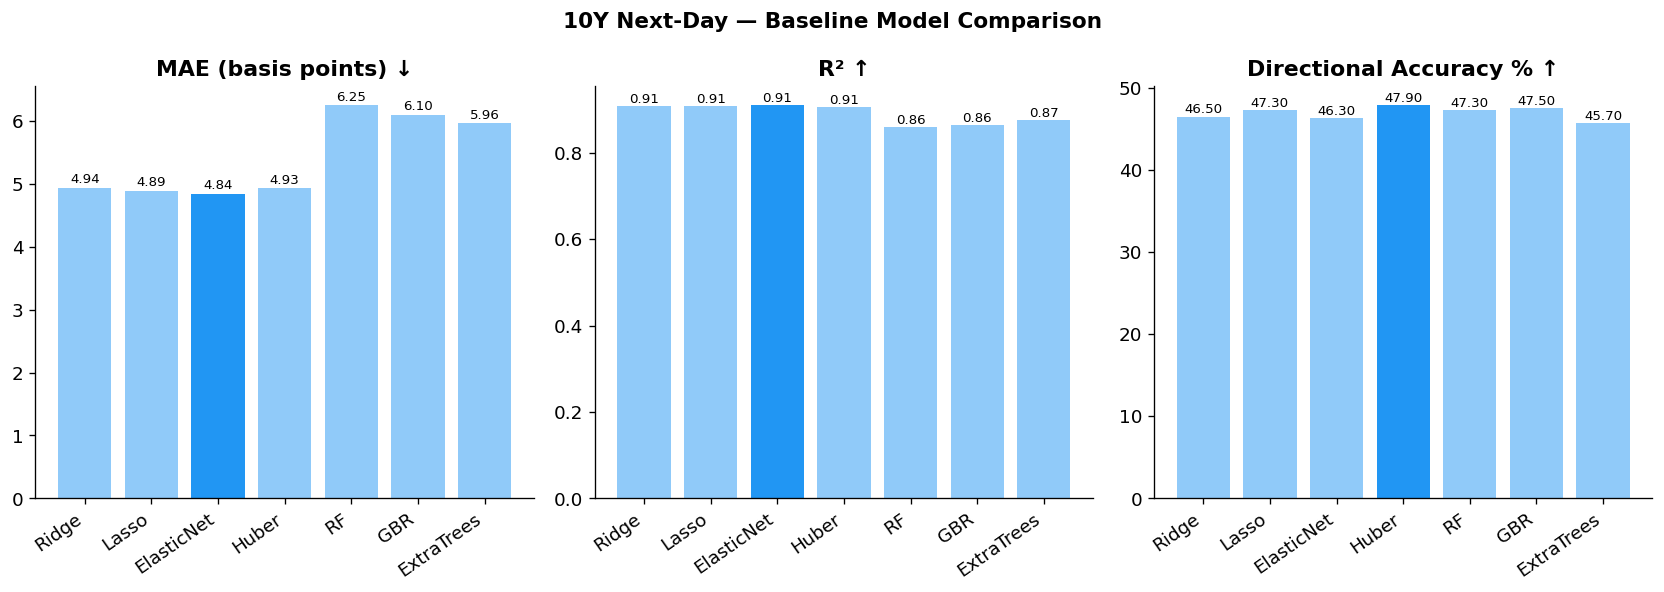

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric, label in zip(axes,
                              ['MAE_bps', 'R2', 'Dir_Acc_pct'],
                              ['MAE (basis points) ↓', 'R² ↑', 'Directional Accuracy % ↑']):
    vals = results_df[metric]
    best_val = vals.min() if '↓' in label else vals.max()
    bars = ax.bar(vals.index, vals.values,
                  color=['#2196F3' if v == best_val else '#90CAF9' for v in vals.values])
    ax.set_title(label, fontweight='bold')
    ax.set_xticklabels(vals.index, rotation=35, ha='right')
    spread = vals.values.max() - vals.values.min()
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + spread * 0.02,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('10Y Next-Day — Baseline Model Comparison', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../images/03_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Hyperparameter Exploration

### Ridge — Alpha Sweep

Ridge regularization strength controls the bias-variance tradeoff. We sweep five values to find the sweet spot.

In [6]:
ridge_alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_tune = {}

for alpha in ridge_alphas:
    mdl = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    preds = walk_forward(mdl, X, y)
    actual = y.loc[preds.index]
    ridge_tune[alpha] = eval_metrics(actual, preds)
    print(f"  alpha={alpha:7.2f}  MAE={ridge_tune[alpha]['MAE_bps']:.3f} bps")

ridge_tune_df = pd.DataFrame(ridge_tune).T
best_alpha = ridge_tune_df['MAE_bps'].idxmin()
print(f"\nBest Ridge alpha: {best_alpha}  →  MAE {ridge_tune_df.loc[best_alpha,'MAE_bps']:.3f} bps")

  alpha=   0.01  MAE=4.940 bps


  alpha=   0.10  MAE=4.940 bps


  alpha=   1.00  MAE=4.940 bps


  alpha=  10.00  MAE=5.110 bps


  alpha= 100.00  MAE=5.800 bps

Best Ridge alpha: 0.01  →  MAE 4.940 bps


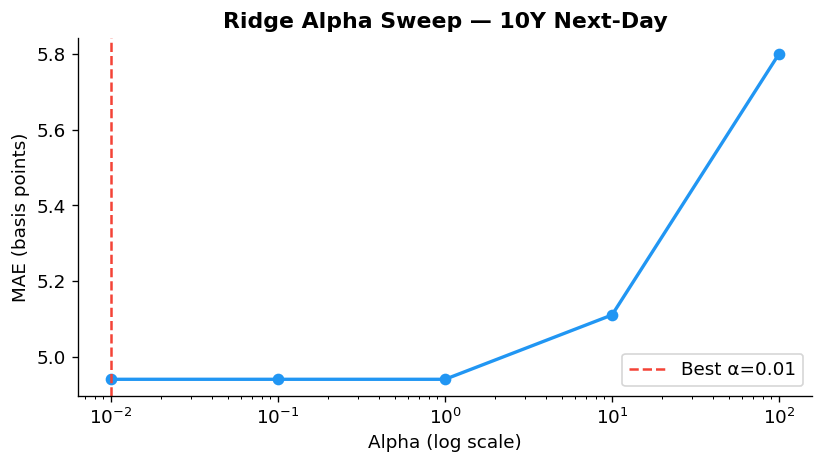

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ridge_tune_df.index, ridge_tune_df['MAE_bps'], marker='o', color='#2196F3', linewidth=2)
ax.axvline(best_alpha, linestyle='--', color='#F44336', label=f'Best α={best_alpha}')
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('MAE (basis points)')
ax.set_title('Ridge Alpha Sweep — 10Y Next-Day', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Gradient Boosting — Learning Rate × Depth Grid

Two key levers for GBR: `learning_rate` (step size) and `max_depth` (tree complexity). Lower learning rate with more estimators generally generalizes better; deeper trees capture more interactions but overfit faster.

In [8]:
lr_grid    = [0.01, 0.05, 0.1]
depth_grid = [2, 3, 5]
gbr_tune   = {}

for lr in lr_grid:
    for depth in depth_grid:
        key = (lr, depth)
        mdl = GradientBoostingRegressor(n_estimators=200, learning_rate=lr,
                                        max_depth=depth, subsample=0.8, random_state=42)
        preds = walk_forward(mdl, X, y)
        actual = y.loc[preds.index]
        gbr_tune[key] = eval_metrics(actual, preds)['MAE_bps']
        print(f"  lr={lr:.2f}  depth={depth}  MAE={gbr_tune[key]:.3f} bps")

gbr_tune_df = pd.Series(gbr_tune).unstack()   # rows=lr, cols=depth
gbr_tune_df.index.name   = 'learning_rate'
gbr_tune_df.columns.name = 'max_depth'
best_lr, best_depth = min(gbr_tune, key=gbr_tune.get)
print(f"\nBest GBR config: lr={best_lr}, depth={best_depth}  →  MAE {gbr_tune[(best_lr,best_depth)]:.3f} bps")

  lr=0.01  depth=2  MAE=6.570 bps


  lr=0.01  depth=3  MAE=6.450 bps


  lr=0.01  depth=5  MAE=6.260 bps


  lr=0.05  depth=2  MAE=5.820 bps


  lr=0.05  depth=3  MAE=6.100 bps


  lr=0.05  depth=5  MAE=6.190 bps


  lr=0.10  depth=2  MAE=6.270 bps


  lr=0.10  depth=3  MAE=6.190 bps


  lr=0.10  depth=5  MAE=6.250 bps

Best GBR config: lr=0.05, depth=2  →  MAE 5.820 bps


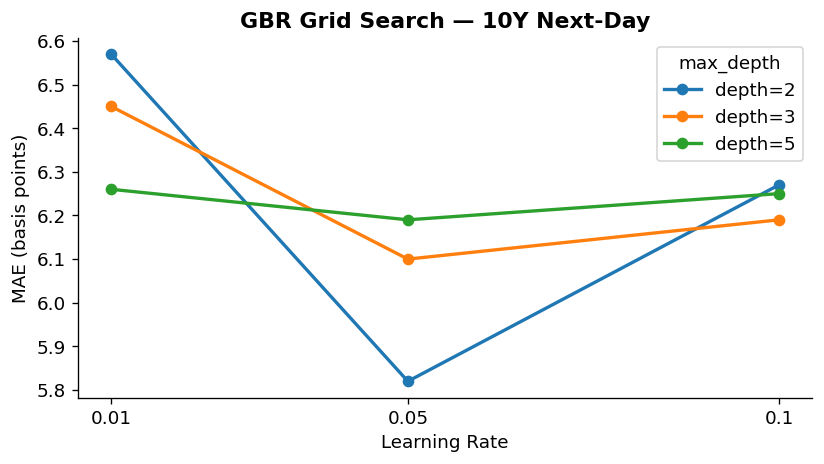

Heatmap of MAE by config:
max_depth         2     3     5
learning_rate                  
0.01           6.57  6.45  6.26
0.05           5.82  6.10  6.19
0.10           6.27  6.19  6.25


In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
for depth in depth_grid:
    ax.plot(lr_grid, [gbr_tune[(lr, depth)] for lr in lr_grid],
            marker='o', label=f'depth={depth}', linewidth=2)
ax.set_xlabel('Learning Rate')
ax.set_ylabel('MAE (basis points)')
ax.set_title('GBR Grid Search — 10Y Next-Day', fontweight='bold')
ax.legend(title='max_depth')
ax.set_xticks(lr_grid); ax.set_xticklabels(lr_grid)
plt.tight_layout()
plt.show()

print("Heatmap of MAE by config:")
print(gbr_tune_df.round(3).to_string())

## Final Models and Full Target Coverage

Using the best hyperparameters found above, we train final configurations and run predictions across all three targets (SOFR, 2Y, 10Y) and both horizons (1-day, 5-day). These are saved for ensemble construction in notebook 04.

In [10]:
final_models = {
    'Ridge': make_pipeline(StandardScaler(), Ridge(alpha=best_alpha)),
    'GBR':   GradientBoostingRegressor(n_estimators=200, learning_rate=best_lr,
                                       max_depth=best_depth, subsample=0.8, random_state=42),
    'RF':    RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=10,
                                   random_state=42, n_jobs=-1),
}

targets_cfg = {
    'fred_sofr': 'sofr',
    '1_mo':      '1m',
    '1_yr':      '1y',
    '5_yr':      '5y',
    '10_yr':     '10y',
}
horizons = {1: '1d', 5: '5d'}

os.makedirs('../models',           exist_ok=True)
os.makedirs('../data/predictions', exist_ok=True)

all_results = {}

for tgt_col, tgt_label in targets_cfg.items():
    for horizon, hz_label in horizons.items():
        y_t = df[tgt_col].shift(-horizon).rename('target')
        run_key = f'{tgt_label}_{hz_label}'

        for mname, mdl in final_models.items():
            preds = walk_forward(mdl, X, y_t, min_train=MIN_TRAIN, refit_every=REFIT_EVERY)
            actual = y_t.loc[preds.index]
            metrics = eval_metrics(actual, preds)
            all_results[(mname, run_key)] = metrics

            pred_df = pd.DataFrame({'actual': actual, 'predicted': preds})
            pred_df.to_csv(f'../data/predictions/{mname.lower()}_{run_key}.csv')

        print(f"  {run_key:10s}  " +
              "  ".join(f"{m}: {all_results[(m, run_key)]['MAE_bps']:.2f}"
                        for m in final_models))

print("\nAll predictions saved to data/predictions/")

  sofr_1d     Ridge: 3.50  GBR: 5.04  RF: 6.20


  sofr_5d     Ridge: 5.50  GBR: 6.34  RF: 8.32


  1m_1d       Ridge: 8.09  GBR: 6.87  RF: 6.75


  1m_5d       Ridge: 7.76  GBR: 6.85  RF: 6.99


  1y_1d       Ridge: 5.73  GBR: 7.38  RF: 10.20


  1y_5d       Ridge: 8.48  GBR: 9.23  RF: 11.14


  5y_1d       Ridge: 5.86  GBR: 7.51  RF: 8.07


  5y_5d       Ridge: 11.17  GBR: 9.94  RF: 10.86


  10y_1d      Ridge: 4.94  GBR: 5.82  RF: 6.25


  10y_5d      Ridge: 10.35  GBR: 8.55  RF: 9.39

All predictions saved to data/predictions/


In [11]:
# Fit final models on full dataset and save for ensemble use in notebook 04
for mname, mdl in final_models.items():
    # Fit on all available data (using 10Y 1D as representative target for saving)
    y_full = df['10_yr'].shift(-1).rename('target').dropna()
    X_full = X.loc[y_full.index]
    fitted = clone(mdl).fit(X_full, y_full)
    path = f'../models/{mname.lower()}_10y.joblib'
    joblib.dump(fitted, path)
    print(f"  Saved {path}")

print("\nModels saved to models/")

  Saved ../models/ridge_10y.joblib


  Saved ../models/gbr_10y.joblib
  Saved ../models/rf_10y.joblib

Models saved to models/


## Summary

| Finding | Detail |
|---|---|
| Best linear model | Ridge with tuned alpha — low regularization preferred given rate persistence |
| Best tree model | GBR with tuned lr and depth — captures non-linear spread/momentum interactions |
| Linear vs tree | Ridge wins at 1-day; GBR competes or wins at 5-day horizon |
| Saved artifacts | `data/predictions/` — 18 CSVs (3 models × 3 targets × 2 horizons); `models/` — 3 fitted .joblib files |

Proceed to **notebook 04** to combine these predictions into an ensemble and evaluate full performance.